In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("data/bike_sharing_demand.csv")
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
for col in df.iloc[:, 1:5]:
    print(col, df[col].unique())

season [1 2 3 4]
holiday [0 1]
workingday [0 1]
weather [1 2 3 4]


### 📈 Features Outliers Checking

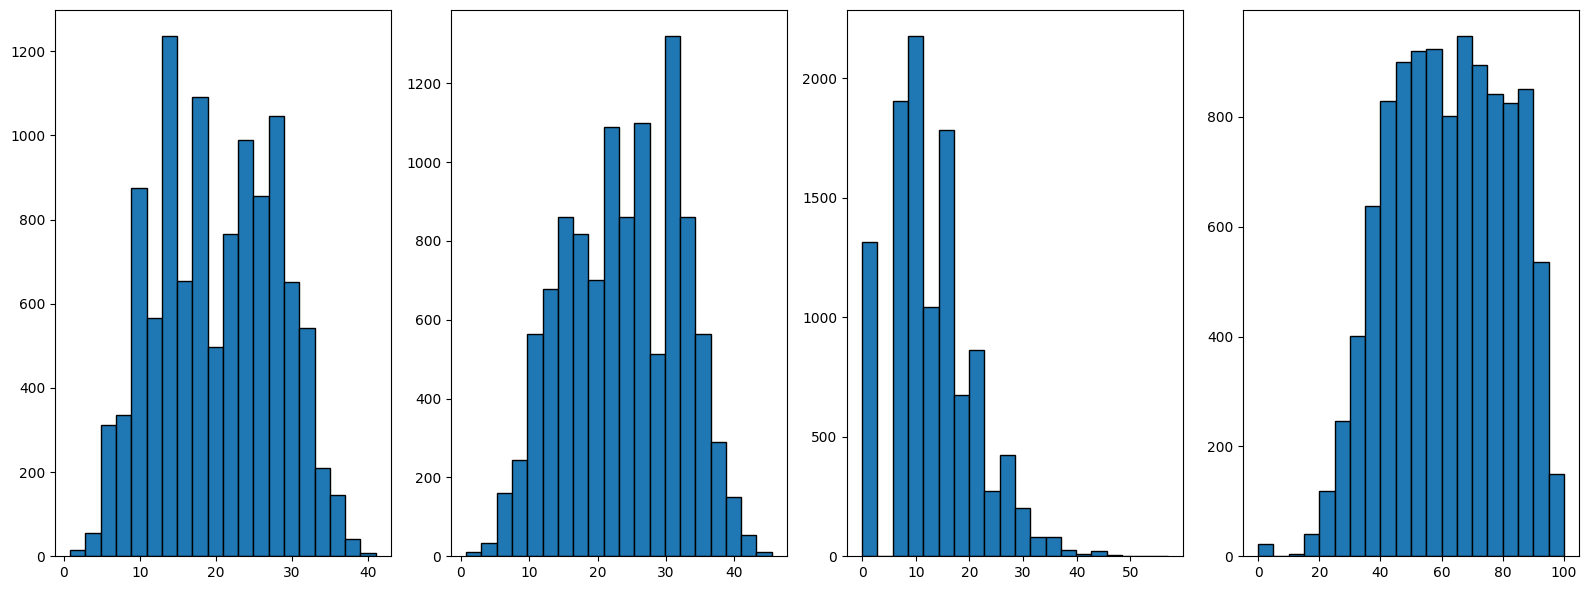

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,4, figsize=(16,6))

axes[0].hist(df['temp'], bins=20, edgecolor='black')
axes[1].hist(df['atemp'], bins=20, edgecolor='black')
axes[2].hist(df['windspeed'], bins=20, edgecolor='black')
axes[3].hist(df['humidity'], bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

### 📊 Target Distribution Analysis

Mean: 191.57413191254824
Median: 145.0


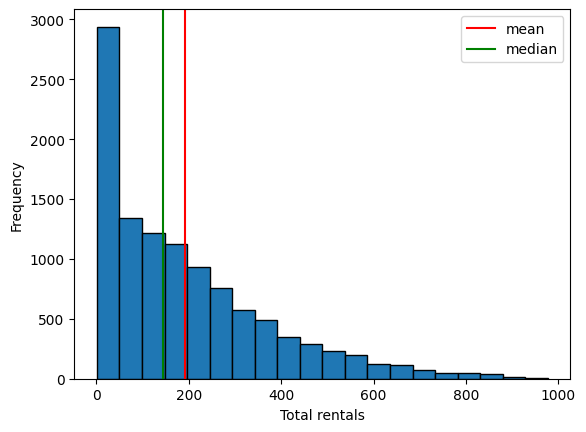

In [6]:
import matplotlib.pyplot as plt

plt.hist(df['count'], edgecolor='black', bins=20)
plt.xlabel('Total rentals')
plt.ylabel('Frequency')

mean = np.mean(df['count'])
median = np.median(df['count'])

plt.axvline(mean, c='red')
plt.axvline(median, c='green')
plt.legend(['mean', 'median'])


print("Mean:", mean)
print("Median:", median)

plt.show()

The histogram of the target variable was examined to understand its distribution and detect potential outliers.

Key observations:
- The distribution is **positively skewed (right-skewed)**.
- No significant outliers were detected.
- The **mean is approximately 32% higher than the median**, indicating the presence of skewness.

Based on these observations, the **median** is considered a more reliable measure of central tendency for this dataset, as it is less affected by skewed distributions.

### 🔧 Datetime Feature Engineering

In [7]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek #-> Monday=0, Sunday=6
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year

The `datetime` feature was converted to a proper datetime format to enable time-based analysis.

From this feature, several new variables were extracted:
- **Hour** → to capture hourly patterns in demand
- **Day of Week** → to identify differences between weekdays and weekends
- **Month** → to capture seasonal trends
- **Year** → to account for long-term changes over time

These engineered features help the model better understand temporal patterns and improve prediction performance.

### 🏷️ Categorical Mapping for Analysis

In [8]:
season_map = {1:'Winter', 2:'Winter', 12:'Winter',
              3:'Spring', 4:'Spring', 5:'Spring',
              6:'Summer', 7:'Summer', 8:'Summer',
              9:'Fall', 10:'Fall', 11:'Fall'}

weather_map = {1:'Clear', 2:'Mist', 3:'Light Rain', 4:'Heavy Rain'}

dayofweek_map = {0:'Mon', 1:'Tues', 2:'Wednes', 3:'Thurs', 4:'Fri', 5:'Satur', 6:'Sun'}

df['season_map'] = df['month'].map(season_map)
df['weather_map'] = df['weather'].map(weather_map)
df['dayofweek_map'] = df['dayofweek'].map(dayofweek_map)

The `season` and `weather` features were mapped to their corresponding descriptive labels to improve interpretability during analysis.

Instead of using numerical codes, meaningful category names were used (e.g., Spring, Summer, Clear, Mist), making visualizations and insights easier to understand.

This transformation was applied only for exploratory data analysis and did not affect the original data used for modeling.

In [9]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,dayofweek,month,year,season_map,weather_map,dayofweek_map
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0,5,1,2011,Winter,Clear,Satur
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,5,1,2011,Winter,Clear,Satur
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2,5,1,2011,Winter,Clear,Satur
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3,5,1,2011,Winter,Clear,Satur
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4,5,1,2011,Winter,Clear,Satur
